### Entrenamiento de Modelos de Predicción

AndesLink Servicios Digitales S.A.

#### 1. Configuración del Entorno y Herramientas

En esta celda se cargan todas las librerías necesarias para el procesamiento de datos, la construcción de modelos, la evaluación de métricas y el registro de experimentos con MLflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
import mlflow
import mlflow.sklearn
import joblib
import os
from sklearn.metrics import accuracy_score, f1_score
import joblib

#### 2. Carga del Dataset Procesado
Se importa el conjunto de datos para iniciar la etapa de entrenamiento.

In [2]:
data = pd.read_csv('../data/processed/churn_sintetico_EDA.csv')
df = pd.DataFrame(data)
df

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,16,57.37,1002.70,1,1,46.59,mensual,debito,movil,0,0,1,centro,25,0,1
4996,54,74.45,4070.99,1,1,196.65,anual,debito,movil,0,1,4,sur,19,0,0
4997,60,44.96,2679.98,1,0,87.63,mensual,transferencia,fibra,1,0,2,centro,21,0,0
4998,49,63.03,3153.70,2,2,113.46,mensual,credito,cable,1,1,1,norte,65,0,1


#### 3. Preprocesamiento de Datos

Antes de entrenar, preparamos las variables. En esta etapa se eliminan identificadores innecesarios, se codifican las variables categóricas (como el tipo de contrato) y se escalan las variables numéricas para normalizar sus rangos.

##### Mapeo de valores para Categoría 
Contrato: Mensual: 0, Anual: 1, Bianual: 2

Pago: Transferencia: 0, Debito: 1, Efectivo: 2, Credito: 3

Internet: Cable: 0, Fibra: 1, Movil: 2, Ninguno: 3

Zona: Centro: 0, Norte: 1, Oeste: 2, Sur: 3

In [3]:
encoder_contract = OrdinalEncoder(categories=[['mensual', 'anual', 'bianual']])
df[['contract_type']] = encoder_contract.fit_transform(df[['contract_type']])

In [4]:
encoder_payment = OrdinalEncoder(categories=[['transferencia', 'debito', 'efectivo', 'credito']])
df[['payment_method']] = encoder_payment.fit_transform(df[['payment_method']])

In [5]:
encoder_internet = OrdinalEncoder(categories=[['cable', 'fibra', 'movil', 'ninguno']])
df[['internet_service']] = encoder_internet.fit_transform(df[['internet_service']])

In [6]:
encoder_region = OrdinalEncoder(categories=[['centro', 'norte', 'oeste', 'sur']])
df[['region']] = encoder_region.fit_transform(df[['region']])

#### 4. División del Conjunto de Datos
Dividimos los datos en Entrenamiento (Train) y Prueba (Test) para validar la capacidad de generalización de los modelos.

In [7]:
columnas_X = ['tenure_months', 'monthly_charge', 'support_tickets', 
              'late_payments', 'avg_monthly_usage_gb', 'contract_type', 'customer_age']
X = df[columnas_X]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
columnas_num = ['tenure_months', 'monthly_charge', 'support_tickets', 
                'late_payments', 'avg_monthly_usage_gb', 'customer_age']

X_train[columnas_num] = scaler.fit_transform(X_train[columnas_num])
X_test[columnas_num] = scaler.transform(X_test[columnas_num])

#### 5. Definición y Ajuste de Modelos
Instanciamos los algoritmos que vamos a comparar: Regresión Logística y Árbol de Decisión.

##### Entrenamiento de Arbol de Decision 

In [8]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight=  {0:1,1:1.5}, criterion= 'gini')
arbol.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 1, 1: 1.5}"


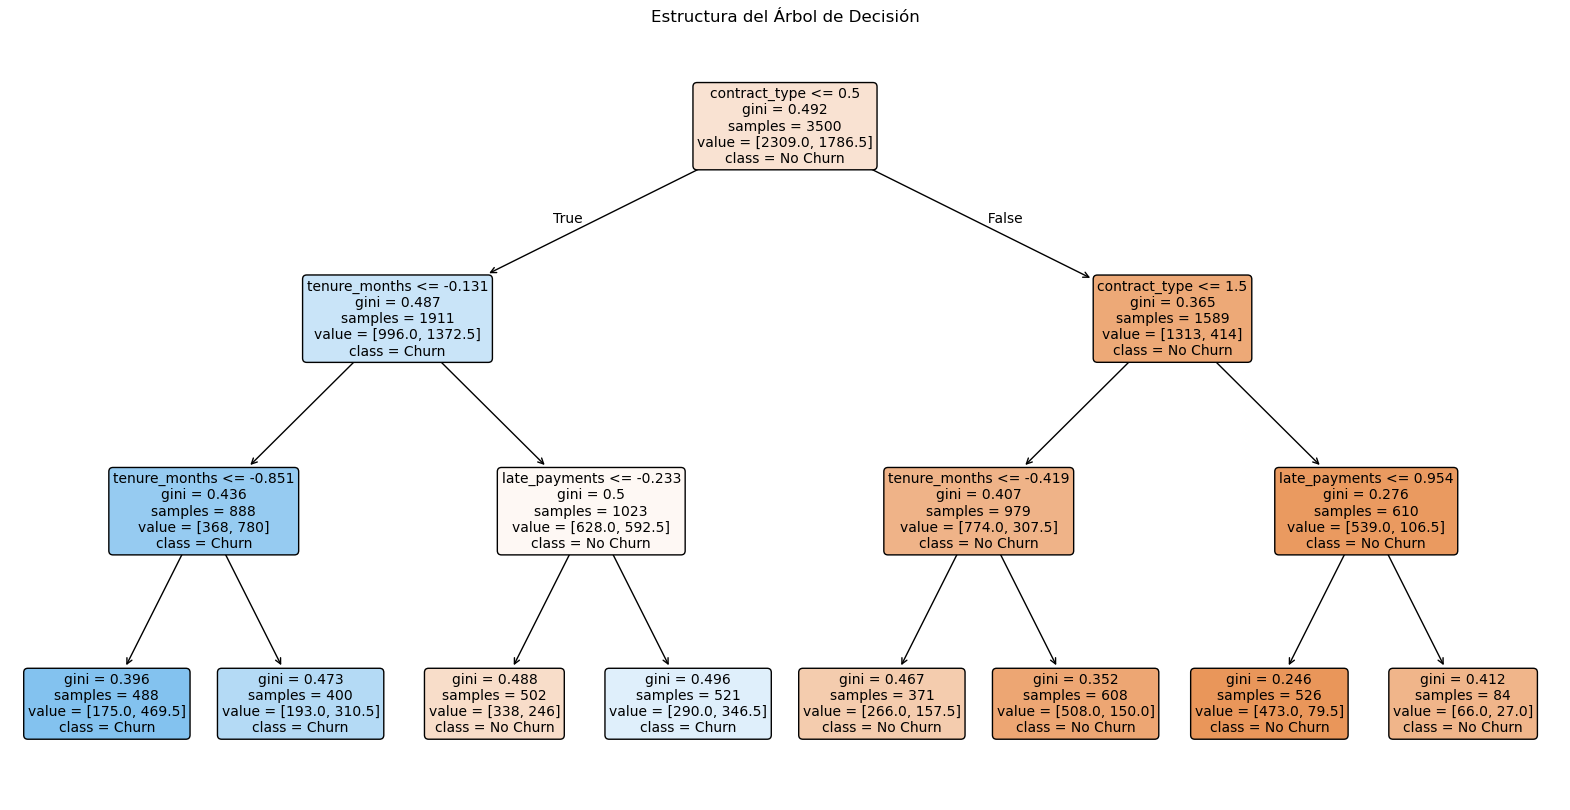

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(arbol, 
          feature_names=columnas_X, 
          class_names=['No Churn', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Estructura del Árbol de Decisión")
plt.show()

In [10]:
pred_arbol = arbol.predict(X_test)
print(classification_report(y_test, pred_arbol))

              precision    recall  f1-score   support

           0       0.78      0.71      0.74       989
           1       0.52      0.62      0.57       511

    accuracy                           0.68      1500
   macro avg       0.65      0.66      0.66      1500
weighted avg       0.69      0.68      0.68      1500



<Figure size 800x600 with 0 Axes>

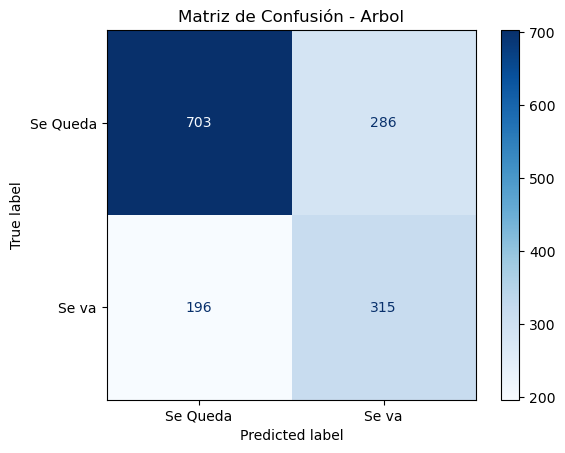

In [11]:
cm = confusion_matrix(y_test, pred_arbol)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda', 'Se va'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - Arbol")
plt.show()

C:\Users\rubik\AppData\Local\Temp\ipykernel_12528\4086039701.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')


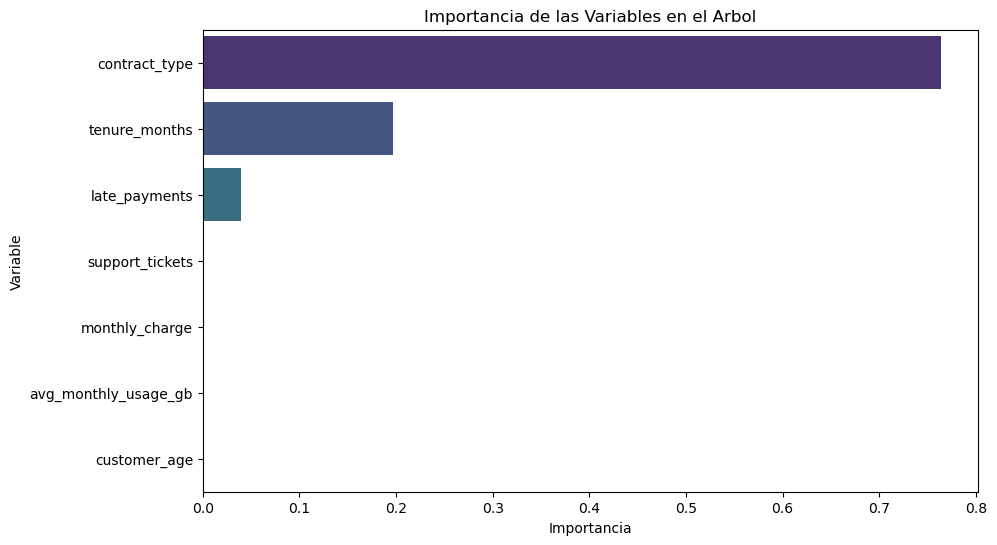

In [12]:
importancias = arbol.feature_importances_
feature_importance_df = pd.DataFrame({'Variable': columnas_X, 'Importancia': importancias})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')
plt.title("Importancia de las Variables en el Arbol")
plt.show()

##### Entrenamiento del modelo Regresion logistica

In [13]:
modelo = LogisticRegression(max_iter=1000, penalty='l1', class_weight= {0:1,1:1.5}, solver='liblinear', random_state= 42 )
modelo.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 1.5}"
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
predicciones = modelo.predict(X_test)

print(f"Precisión: {accuracy_score(y_test, predicciones)}")
print(classification_report(y_test, predicciones))

Precisión: 0.6866666666666666
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       989
           1       0.53      0.63      0.58       511

    accuracy                           0.69      1500
   macro avg       0.66      0.67      0.66      1500
weighted avg       0.70      0.69      0.69      1500



#### 6. MLflow y Persistencia de Modelos
Registro de parámetros, métricas y guardado físico de los archivos .joblib en la carpeta de destino.

In [15]:
folder_path = '../models'
os.makedirs(folder_path, exist_ok=True)


mlflow.set_experiment("Analisis_Churn_Clientes")


with mlflow.start_run(run_name="Regresion_Logistica"):
    
    mlflow.log_param("model_type", "LogisticRegression")
    
    
    y_pred_log = modelo.predict(X_test)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_log))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_log, average='weighted'))
    
   
    mlflow.sklearn.log_model(modelo, "log_reg_model")
    
    
    joblib.dump(modelo, os.path.join(folder_path, 'logistic_regression.joblib'))


with mlflow.start_run(run_name="Arbol_Decision"):
    mlflow.log_param("model_type", "DecisionTreeClassifier")
    
    y_pred_tree = arbol.predict(X_test)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_tree))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_tree, average='weighted'))
    
    
    mlflow.sklearn.log_model(arbol, "tree_model")
    
    
    joblib.dump(arbol, os.path.join(folder_path, 'decision_tree.joblib'))


joblib.dump(scaler, os.path.join(folder_path, 'scaler.joblib'))
joblib.dump(encoder_contract, os.path.join(folder_path, 'encoder_contract.joblib'))
joblib.dump(encoder_payment, os.path.join(folder_path, 'encoder_payment.joblib'))
joblib.dump(encoder_internet, os.path.join(folder_path, 'encoder_internet.joblib'))
joblib.dump(encoder_region, os.path.join(folder_path, 'encoder_region.joblib'))

print(f"Éxito: Modelos y preprocesadores guardados en {os.path.abspath(folder_path)}")


2026/05/26 14:16:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 14:16:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/26 14:17:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 14:17:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Éxito: Modelos y preprocesadores guardados en c:\Users\rubik\OneDrive\Escritorio\Proyecto Lab. Mineria de datos\models
